# EEG_19 — Session-Level Clustering: Test-Retest della Firma di Connettività

**Domanda**: la firma di connettività di un soggetto è stabile tra le sue 5 sessioni?

**Motivazione**: in EEG_16b abbiamo clusterizzato i soggetti usando la media adj su TUTTI
i trial (tutte le sessioni). Questo notebook verifica se quella media è rappresentativa:
calcoliamo una media adj per SESSIONE (invece che per soggetto) e chiediamo:

1. **Le sessioni dello stesso soggetto si assomigliano?** (NMI identità soggetto)
2. **I fenotipi C0/C1 sono stabili nel tempo?** (le sessioni dei soggetti C1 cadono sempre dalla parte fronto-occipitale?)
3. **F3–PO8 è stabile tra sessioni nei soggetti C1?** (test diretto sul meccanismo)

**Pipeline**: per ogni soggetto × sessione → mean adj ~110 trial → vettore 1830-dim → 365 vettori totali

**Differenza rispetto a EEG_16b**:
- EEG_16b: 73 vettori (1 per soggetto, media su ~525 trial)
- EEG_19: 365 vettori (5 per soggetto, media su ~110 trial per sessione)

## §1 — Setup e caricamento indice sessioni

In [1]:
import json, logging, math, re
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from scipy.stats import mannwhitneyu, pearsonr
from tqdm.auto import tqdm

logging.basicConfig(level=logging.INFO,
                    format='%(asctime)s %(levelname)-8s %(message)s',
                    datefmt='%H:%M:%S')
log = logging.getLogger('eeg19')

project_root = next((p for p in [Path.cwd()] + list(Path.cwd().parents)
                     if (p / '.git').exists()), Path.cwd())
FIG_DIR  = project_root / 'figures'; FIG_DIR.mkdir(exist_ok=True)
CKPT_DIR = project_root / 'models' / 'eeg19'; CKPT_DIR.mkdir(parents=True, exist_ok=True)
EEG16_CKPT = project_root / 'models' / 'eeg16'

METRIC       = 'abs_pcc'
N_CHAN       = 61
N_TRIU       = N_CHAN * (N_CHAN - 1) // 2   # 1830
EXCLUDE_SUBJ = [22]                          # P022 outlier
RANDOM_SEED  = 42
triu_idx     = np.triu_indices(N_CHAN, k=1)

# ── Carica label cluster da EEG_16b (C0/C1 per soggetto) ────────────────────
GRAPH_CACHE = EEG16_CKPT / f'feat_graph_{METRIC}.npz'
HG_CACHE    = EEG16_CKPT / f'feat_hg_{METRIC}.npz'
assert GRAPH_CACHE.exists(), f'Manca {GRAPH_CACHE} — esegui prima EEG_16b'

_g = np.load(GRAPH_CACHE); FEAT_G_16 = _g['feats']; SUBJ_G_16 = _g['subj_ids'].tolist()
_h = np.load(HG_CACHE);    FEAT_H_16 = _h['feats']; SUBJ_H_16 = _h['subj_ids'].tolist()

# Filtra P022
keep_g = [i for i, s in enumerate(SUBJ_G_16) if s not in EXCLUDE_SUBJ]
FEAT_G_16 = FEAT_G_16[keep_g]; SUBJ_G_16 = [SUBJ_G_16[i] for i in keep_g]
keep_h = [i for i, s in enumerate(SUBJ_H_16) if s not in EXCLUDE_SUBJ]
FEAT_H_16 = FEAT_H_16[keep_h]; SUBJ_H_16 = [SUBJ_H_16[i] for i in keep_h]

# Ricalcola clustering EEG_16b (ipergrafo k=2)
scaler_h = StandardScaler()
Z_h = PCA(n_components=20, random_state=RANDOM_SEED).fit_transform(
         scaler_h.fit_transform(FEAT_H_16))
LABELS_16B = KMeans(n_clusters=2, n_init=30, random_state=RANDOM_SEED).fit_predict(Z_h)
SUBJ_TO_LABEL16 = {s: int(LABELS_16B[i]) for i, s in enumerate(SUBJ_H_16)}
log.info(f'Label EEG_16b ricaricate: C0={sum(v==0 for v in SUBJ_TO_LABEL16.values())} '
         f'C1={sum(v==1 for v in SUBJ_TO_LABEL16.values())}')

CLUSTER_NAMES = {0: 'Fronto-motor', 1: 'Fronto-occipital'}
COLORS_CLUSTER = {0: plt.cm.tab10(0.05), 1: plt.cm.tab10(0.15)}

log.info(f'Setup completato — project_root: {project_root}')

21:15:48 INFO     Label EEG_16b ricaricate: C0=36 C1=37
21:15:48 INFO     Setup completato — project_root: /home/daniele_u/miralis-hypergraph-imagined-speech


## §2 — Calcola mean adj per sessione

Per ogni soggetto × sessione: media adj sui ~110 trial di quella sessione.
Produce una matrice (n_sessions_total, 1830) dove ogni riga = una sessione.

Cache: `models/eeg19/feat_session_abs_pcc.npz`

In [2]:
_PAT = re.compile(r'^P(\d+)_S(\d+)$')

def build_session_index(metric):
    """Ritorna dict: (subj_id, sess_id) -> [paths]"""
    root = project_root / 'data' / f'hypergraphs_pruned_{metric}'
    idx  = defaultdict(list)
    if not root.exists():
        log.warning(f'Directory non trovata: {root}')
        return idx
    for p in sorted(root.rglob('trial_*.pt')):
        m = _PAT.match(p.parent.name)
        if m:
            sid, sess = int(m.group(1)), int(m.group(2))
            idx[(sid, sess)].append(p)
    return idx

SESSION_CACHE = CKPT_DIR / f'feat_session_{METRIC}.npz'

if SESSION_CACHE.exists():
    log.info('Cache sessioni trovata — caricamento veloce')
    _sc = np.load(SESSION_CACHE)
    FEAT_SESS  = _sc['feats']          # (n_sessions, 1830)
    SESS_SUBJ  = _sc['subj_ids'].tolist()
    SESS_SESS  = _sc['sess_ids'].tolist()
else:
    IDX_SESS = build_session_index(METRIC)
    log.info(f'Sessioni trovate: {len(IDX_SESS)}')

    feat_list, subj_list, sess_list = [], [], []
    for (sid, sess), paths in tqdm(sorted(IDX_SESS.items()), desc='Sessioni'):
        if sid in EXCLUDE_SUBJ:
            continue
        adjs = []
        for p in paths:
            try:
                d = torch.load(p, weights_only=False)
                adj = d['adj'].float().numpy()
                if adj.shape == (N_CHAN, N_CHAN):
                    adjs.append(adj[triu_idx])
            except Exception:
                continue
        if len(adjs) < 5:
            continue
        feat_list.append(np.mean(adjs, axis=0))
        subj_list.append(sid)
        sess_list.append(sess)

    FEAT_SESS = np.array(feat_list)
    SESS_SUBJ = subj_list
    SESS_SESS = sess_list
    np.savez(SESSION_CACHE, feats=FEAT_SESS,
             subj_ids=np.array(SESS_SUBJ), sess_ids=np.array(SESS_SESS))
    log.info(f'Cache salvata: {SESSION_CACHE}')

log.info(f'Sessioni totali: {len(SESS_SUBJ)}')
log.info(f'Soggetti unici: {len(set(SESS_SUBJ))}')
log.info(f'Sessioni per soggetto: {np.unique([SESS_SUBJ.count(s) for s in set(SESS_SUBJ)])}')
log.info(f'FEAT_SESS shape: {FEAT_SESS.shape}')

21:15:48 INFO     Sessioni trovate: 357


Sessioni:   0%|          | 0/357 [00:00<?, ?it/s]

21:16:18 INFO     Cache salvata: /home/daniele_u/miralis-hypergraph-imagined-speech/models/eeg19/feat_session_abs_pcc.npz
21:16:18 INFO     Sessioni totali: 352
21:16:18 INFO     Soggetti unici: 73
21:16:18 INFO     Sessioni per soggetto: [1 3 4 5 6]
21:16:18 INFO     FEAT_SESS shape: (352, 1830)


## §3 — PCA: spazio delle sessioni

Visualizza le 365 sessioni nello spazio PCA. Ogni punto = una sessione.

- **Plot A**: colorato per soggetto → le sessioni dello stesso soggetto si raggruppano?
- **Plot B**: colorato per cluster EEG_16b (C0/C1) → i soggetti C1 sono nella stessa zona?
- **Plot C**: colorato per numero di sessione (1-5) → c'è drift temporale?

21:16:18 INFO     Varianza spiegata PCA (20 comp): 44.9%
21:16:18 INFO     Varianza PC1: 10.4%  PC2: 3.9%


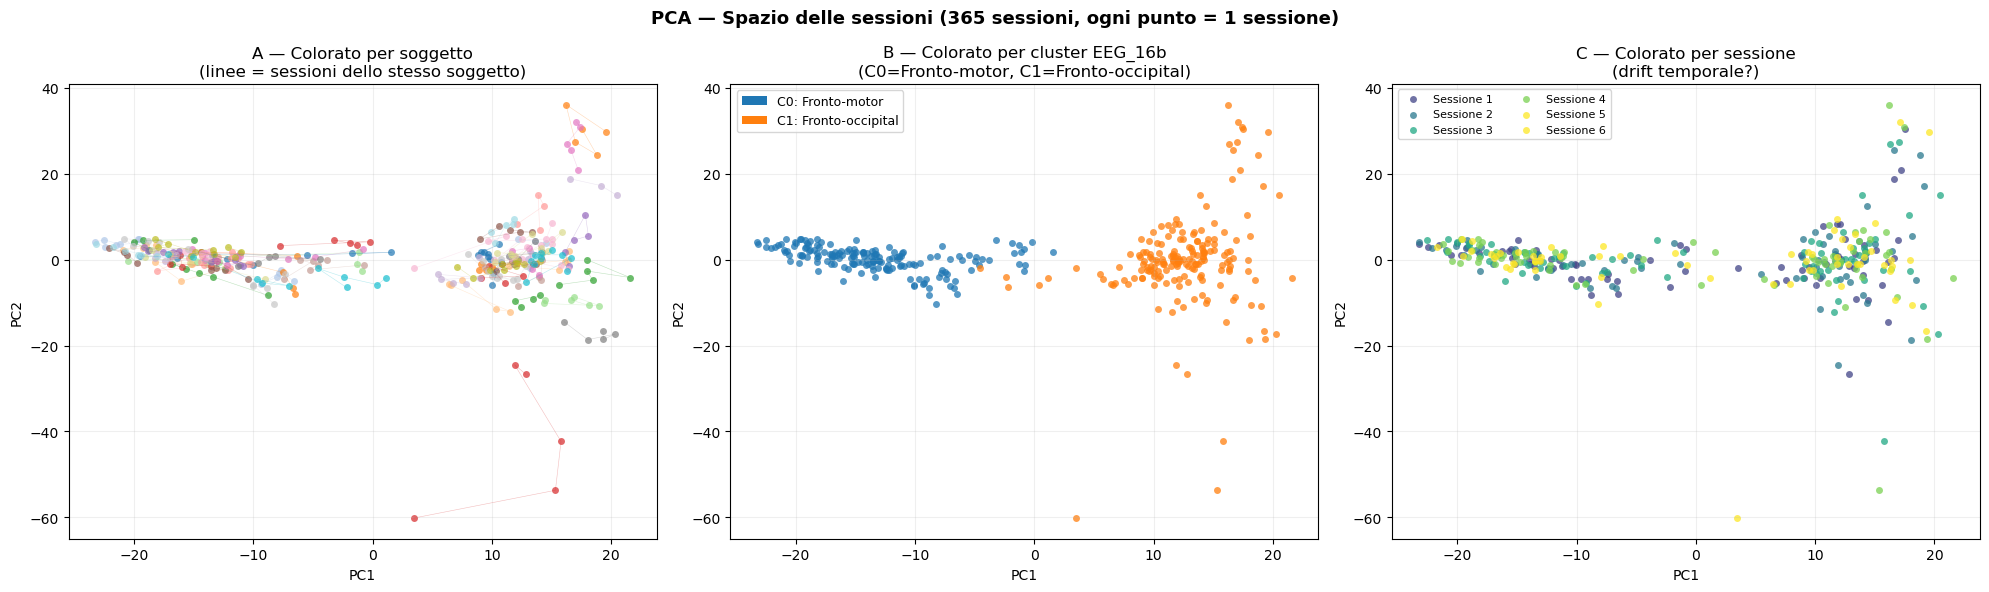

21:16:20 INFO     Salvato: eeg19_pca_sessions.png


In [3]:
scaler_s = StandardScaler()
X_s = scaler_s.fit_transform(FEAT_SESS)
pca_s = PCA(n_components=20, random_state=RANDOM_SEED)
Z_s   = pca_s.fit_transform(X_s)
log.info(f'Varianza spiegata PCA (20 comp): {pca_s.explained_variance_ratio_.sum():.1%}')
log.info(f'Varianza PC1: {pca_s.explained_variance_ratio_[0]:.1%}  '
         f'PC2: {pca_s.explained_variance_ratio_[1]:.1%}')

all_subj_sorted = sorted(set(SESS_SUBJ))
subj_to_color   = {s: cm.tab20(i / len(all_subj_sorted))
                   for i, s in enumerate(all_subj_sorted)}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('PCA — Spazio delle sessioni (365 sessioni, ogni punto = 1 sessione)',
             fontsize=13, fontweight='bold')

# A — colorato per soggetto
ax = axes[0]
for sid in all_subj_sorted:
    mask = [i for i, s in enumerate(SESS_SUBJ) if s == sid]
    ax.scatter(Z_s[mask, 0], Z_s[mask, 1],
               color=subj_to_color[sid], s=25, alpha=0.7, linewidths=0)
    # Connetti le 5 sessioni con linea sottile
    if len(mask) > 1:
        ax.plot(Z_s[mask, 0], Z_s[mask, 1], '-', color=subj_to_color[sid],
                lw=0.4, alpha=0.3)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('A — Colorato per soggetto\n(linee = sessioni dello stesso soggetto)')
ax.grid(alpha=0.2)

# B — colorato per cluster EEG_16b
ax = axes[1]
for i, (sid, sess_id) in enumerate(zip(SESS_SUBJ, SESS_SESS)):
    c = SUBJ_TO_LABEL16.get(sid, -1)
    color = COLORS_CLUSTER.get(c, 'gray')
    ax.scatter(Z_s[i, 0], Z_s[i, 1], color=color, s=25, alpha=0.75, linewidths=0)

from matplotlib.patches import Patch
legend_el = [Patch(facecolor=COLORS_CLUSTER[c],
                   label=f'C{c}: {CLUSTER_NAMES[c]}') for c in [0,1]]
ax.legend(handles=legend_el, fontsize=9)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('B — Colorato per cluster EEG_16b\n(C0=Fronto-motor, C1=Fronto-occipital)')
ax.grid(alpha=0.2)

# C — colorato per sessione (1-5)
ax = axes[2]
cmap_sess = plt.cm.viridis
for sess_num in sorted(set(SESS_SESS)):
    mask = [i for i, s in enumerate(SESS_SESS) if s == sess_num]
    ax.scatter(Z_s[mask, 0], Z_s[mask, 1],
               color=cmap_sess(sess_num / 5), s=25, alpha=0.75, linewidths=0,
               label=f'Sessione {sess_num}')
ax.legend(fontsize=8, ncol=2)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('C — Colorato per sessione\n(drift temporale?)')
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(FIG_DIR / 'eeg19_pca_sessions.png', dpi=130, bbox_inches='tight')
plt.show()
log.info('Salvato: eeg19_pca_sessions.png')

## §4 — Distanza intra-soggetto tra sessioni

Per ogni soggetto: quanto distano le sue 5 sessioni tra loro?

- **dist_intra**: distanza media L2 tra tutte le coppie di sessioni dello stesso soggetto
- **dist_inter**: distanza media L2 tra sessioni di soggetti diversi
- **Ratio dist_intra / dist_inter**: se << 1 → le sessioni di un soggetto si assomigliano
  molto di più tra loro che con sessioni di altri soggetti → firma individuale stabile

21:16:21 INFO     Ratio MW C0 vs C1: C0=0.338 C1=0.428 p=0.073


── Stabilità sessioni: distanza intra vs inter soggetto ──
  Distanza intra-soggetto (media): 2.416 ± 0.876
  Distanza inter-soggetto (media): 5.690
  Ratio intra/inter:               0.425 ± 0.154
  → ratio < 1.0: la sessioni dello stesso soggetto sono più simili tra loro
  → ratio << 0.5: firma individuale molto stabile
  Sogg. con ratio < 0.5: 52/72 (72%)
  Sogg. con ratio < 0.3: 17/72 (24%)


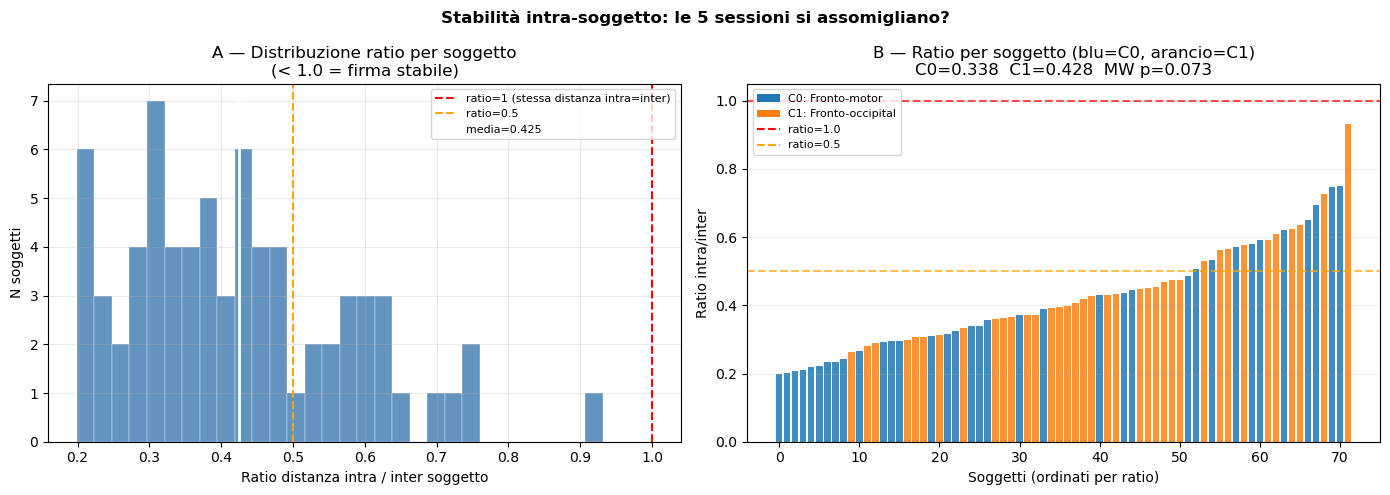

In [4]:
# ── Distanza intra vs inter soggetto ─────────────────────────────────────────
intra_dists = {}   # sid -> lista di distanze tra coppie di sessioni
for sid in set(SESS_SUBJ):
    indices = [i for i, s in enumerate(SESS_SUBJ) if s == sid]
    if len(indices) < 2:
        continue
    dists = []
    for a in range(len(indices)):
        for b in range(a+1, len(indices)):
            dists.append(np.linalg.norm(FEAT_SESS[indices[a]] - FEAT_SESS[indices[b]]))
    intra_dists[sid] = np.mean(dists)

# Distanza inter: campiona N coppie random tra soggetti diversi
rng = np.random.default_rng(42)
inter_sample = []
for _ in range(5000):
    i, j = rng.choice(len(SESS_SUBJ), 2, replace=False)
    if SESS_SUBJ[i] != SESS_SUBJ[j]:
        inter_sample.append(np.linalg.norm(FEAT_SESS[i] - FEAT_SESS[j]))
inter_mean = np.mean(inter_sample)

intra_vals  = np.array(list(intra_dists.values()))
intra_subjs = list(intra_dists.keys())
ratio       = intra_vals / inter_mean

print('── Stabilità sessioni: distanza intra vs inter soggetto ──')
print(f'  Distanza intra-soggetto (media): {intra_vals.mean():.3f} ± {intra_vals.std():.3f}')
print(f'  Distanza inter-soggetto (media): {inter_mean:.3f}')
print(f'  Ratio intra/inter:               {ratio.mean():.3f} ± {ratio.std():.3f}')
print(f'  → ratio < 1.0: la sessioni dello stesso soggetto sono più simili tra loro')
print(f'  → ratio << 0.5: firma individuale molto stabile')
print(f'  Sogg. con ratio < 0.5: {(ratio < 0.5).sum()}/{len(ratio)} ({100*(ratio<0.5).mean():.0f}%)')
print(f'  Sogg. con ratio < 0.3: {(ratio < 0.3).sum()}/{len(ratio)} ({100*(ratio<0.3).mean():.0f}%)')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Stabilità intra-soggetto: le 5 sessioni si assomigliano?',
             fontsize=12, fontweight='bold')

# A — distribuzione ratio
ax = axes[0]
ax.hist(ratio, bins=30, color='steelblue', alpha=0.85, edgecolor='white', lw=0.3)
ax.axvline(1.0, color='red',    lw=1.5, ls='--', label='ratio=1 (stessa distanza intra=inter)')
ax.axvline(0.5, color='orange', lw=1.5, ls='--', label='ratio=0.5')
ax.axvline(ratio.mean(), color='white', lw=2, ls='-', label=f'media={ratio.mean():.3f}')
ax.set_xlabel('Ratio distanza intra / inter soggetto')
ax.set_ylabel('N soggetti')
ax.set_title('A — Distribuzione ratio per soggetto\n(< 1.0 = firma stabile)')
ax.legend(fontsize=8); ax.grid(alpha=0.25)

# B — ratio per soggetto, colorato per cluster
ax = axes[1]
order = np.argsort(ratio)
colors_r = [COLORS_CLUSTER.get(SUBJ_TO_LABEL16.get(intra_subjs[i], -1), 'gray')
            for i in order]
ax.bar(range(len(ratio)), ratio[order], color=colors_r, alpha=0.85, width=0.8)
ax.axhline(1.0, color='red',    lw=1.5, ls='--', alpha=0.7, label='ratio=1.0')
ax.axhline(0.5, color='orange', lw=1.5, ls='--', alpha=0.7, label='ratio=0.5')

# MW C0 vs C1
ratio_c0 = [ratio[intra_subjs.index(s)] for s in intra_subjs
            if SUBJ_TO_LABEL16.get(s,-1) == 0]
ratio_c1 = [ratio[intra_subjs.index(s)] for s in intra_subjs
            if SUBJ_TO_LABEL16.get(s,-1) == 1]
if ratio_c0 and ratio_c1:
    _, p_r = mannwhitneyu(ratio_c0, ratio_c1, alternative='two-sided')
    ax.set_title(f'B — Ratio per soggetto (blu=C0, arancio=C1)\n'
                 f'C0={np.median(ratio_c0):.3f}  C1={np.median(ratio_c1):.3f}  MW p={p_r:.3f}')
    log.info(f'Ratio MW C0 vs C1: C0={np.median(ratio_c0):.3f} C1={np.median(ratio_c1):.3f} p={p_r:.3f}')

ax.legend(handles=[Patch(facecolor=COLORS_CLUSTER[c], label=f'C{c}: {CLUSTER_NAMES[c]}')
                   for c in [0,1]] + [
    plt.Line2D([0],[0], color='red',    ls='--', label='ratio=1.0'),
    plt.Line2D([0],[0], color='orange', ls='--', label='ratio=0.5'),
], fontsize=8)
ax.set_xlabel('Soggetti (ordinati per ratio)'); ax.set_ylabel('Ratio intra/inter')
ax.grid(alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig(FIG_DIR / 'eeg19_intra_inter_ratio.png', dpi=130, bbox_inches='tight')
plt.show()

## §5 — Subject identity recovery (NMI)

Cluster le 365 sessioni con k=N_soggetti. Chiedi: quanto si recupera l'identità del soggetto?

- **NMI = 1.0**: ogni cluster contiene esattamente le sessioni di un soggetto → firma perfetta
- **NMI = 0.0**: cluster casuali, nessuna struttura per soggetto
- **ARI**: come NMI ma corretto per il caso

21:16:22 INFO     Clustering sessioni con k=73...


── Subject Identity Recovery ──
  k = 73 cluster
  NMI (sessioni → soggetto): 0.946  (random baseline: 0.618)
  ARI (sessioni → soggetto): 0.724
  → NMI >> baseline: le sessioni si raggruppano per soggetto

  Purezza cluster per soggetto:
  Media: 0.922  Mediana: 1.000
  Sogg. con purezza=1.0 (tutte le sessioni nello stesso cluster): 56/73 (77%)
  Sogg. con purezza≥0.8: 62/73 (85%)


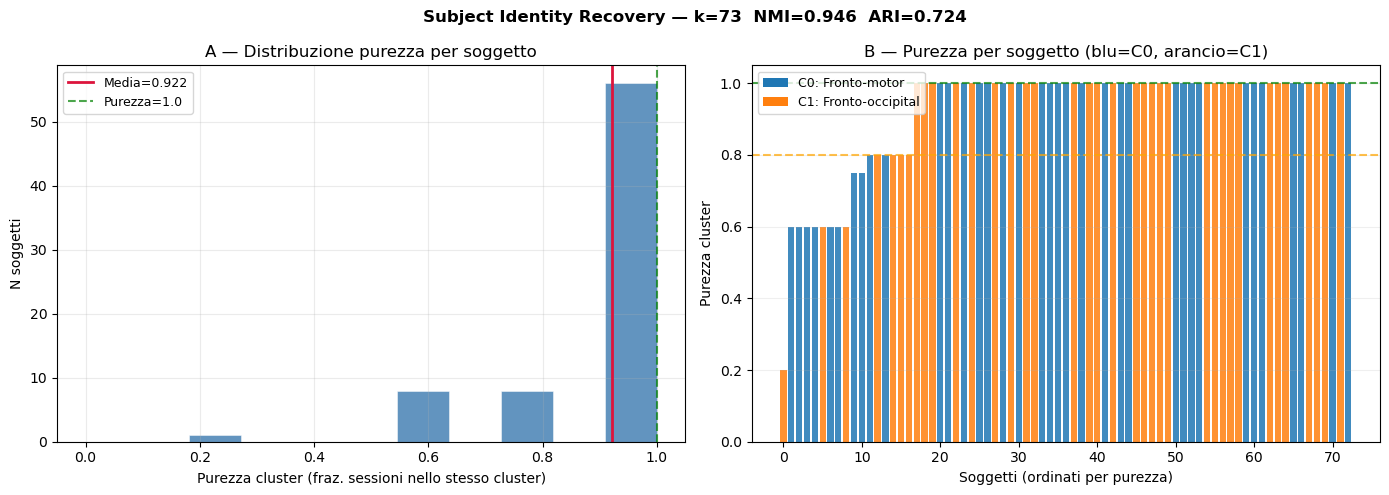

In [5]:
n_subj_unique = len(set(SESS_SUBJ))
log.info(f'Clustering sessioni con k={n_subj_unique}...')

scaler_nmi = StandardScaler()
X_nmi = scaler_nmi.fit_transform(FEAT_SESS)
Z_nmi = PCA(n_components=min(50, len(SESS_SUBJ)-1),
            random_state=RANDOM_SEED).fit_transform(X_nmi)

km_nmi = KMeans(n_clusters=n_subj_unique, n_init=20, random_state=RANDOM_SEED)
labels_km = km_nmi.fit_predict(Z_nmi)

nmi = normalized_mutual_info_score(SESS_SUBJ, labels_km)
ari = adjusted_rand_score(SESS_SUBJ, labels_km)

# Baseline random
nmi_random = np.mean([
    normalized_mutual_info_score(SESS_SUBJ,
        np.random.default_rng(i).permutation(labels_km))
    for i in range(200)
])

print('── Subject Identity Recovery ──')
print(f'  k = {n_subj_unique} cluster')
print(f'  NMI (sessioni → soggetto): {nmi:.3f}  (random baseline: {nmi_random:.3f})')
print(f'  ARI (sessioni → soggetto): {ari:.3f}')
print(f'  → NMI >> baseline: le sessioni si raggruppano per soggetto')

# Per ogni soggetto: quante delle sue sessioni sono nel cluster più frequente?
cluster_purity = {}
for sid in set(SESS_SUBJ):
    sess_idx = [i for i, s in enumerate(SESS_SUBJ) if s == sid]
    if not sess_idx:
        continue
    clust_labels = [labels_km[i] for i in sess_idx]
    most_common = max(set(clust_labels), key=clust_labels.count)
    purity = clust_labels.count(most_common) / len(clust_labels)
    cluster_purity[sid] = purity

purity_vals = np.array(list(cluster_purity.values()))
print(f'\n  Purezza cluster per soggetto:')
print(f'  Media: {purity_vals.mean():.3f}  Mediana: {np.median(purity_vals):.3f}')
print(f'  Sogg. con purezza=1.0 (tutte le sessioni nello stesso cluster): '
      f'{(purity_vals==1.0).sum()}/{len(purity_vals)} ({100*(purity_vals==1.0).mean():.0f}%)')
print(f'  Sogg. con purezza≥0.8: '
      f'{(purity_vals>=0.8).sum()}/{len(purity_vals)} ({100*(purity_vals>=0.8).mean():.0f}%)')

# Plot distribuzione purezza
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Subject Identity Recovery — k={n_subj_unique}  NMI={nmi:.3f}  ARI={ari:.3f}',
             fontsize=12, fontweight='bold')

ax = axes[0]
ax.hist(purity_vals, bins=np.linspace(0,1,12), color='steelblue',
        alpha=0.85, edgecolor='white', lw=0.4)
ax.axvline(purity_vals.mean(), color='crimson', lw=2, label=f'Media={purity_vals.mean():.3f}')
ax.axvline(1.0, color='green', lw=1.5, ls='--', alpha=0.7, label='Purezza=1.0')
ax.set_xlabel('Purezza cluster (fraz. sessioni nello stesso cluster)')
ax.set_ylabel('N soggetti')
ax.set_title('A — Distribuzione purezza per soggetto')
ax.legend(fontsize=9); ax.grid(alpha=0.25)

ax = axes[1]
purity_subjs = list(cluster_purity.keys())
purity_arr   = np.array([cluster_purity[s] for s in purity_subjs])
order_p = np.argsort(purity_arr)
colors_p = [COLORS_CLUSTER.get(SUBJ_TO_LABEL16.get(purity_subjs[i],-1),'gray')
            for i in order_p]
ax.bar(range(len(purity_arr)), purity_arr[order_p], color=colors_p, alpha=0.85, width=0.8)
ax.set_xlabel('Soggetti (ordinati per purezza)')
ax.set_ylabel('Purezza cluster')
ax.set_title('B — Purezza per soggetto (blu=C0, arancio=C1)')
ax.axhline(1.0, color='green',  lw=1.5, ls='--', alpha=0.7)
ax.axhline(0.8, color='orange', lw=1.5, ls='--', alpha=0.7)
ax.legend(handles=[Patch(facecolor=COLORS_CLUSTER[c], label=f'C{c}: {CLUSTER_NAMES[c]}')
                   for c in [0,1]], fontsize=9)
ax.grid(alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig(FIG_DIR / 'eeg19_subject_recovery.png', dpi=130, bbox_inches='tight')
plt.show()

## §6 — Clustering k=2 sulle sessioni: i fenotipi C0/C1 sono stabili?

Cluster le 365 sessioni con k=2 (stessa logica di EEG_16b).
Poi confronta le assegnazioni con le label EEG_16b:

- **ARI(sess_labels, subj_labels_16b)**: alto → le sessioni dei soggetti C0 cadono
  tutte nel cluster sessione-C0, e viceversa per C1
- **Per ogni soggetto**: quante delle sue 5 sessioni concorda con la label EEG_16b?

── Clustering k=2 sessioni vs label EEG_16b ──
  ARI(sessioni-k2, soggetti-EEG16b): 0.933
  NMI(sessioni-k2, soggetti-EEG16b): 0.881
  → ARI > 0.7: le sessioni dei soggetti C0/C1 cadono nel cluster corretto

  Concordanza per soggetto (fraz. sessioni con label corretta):
  Media: 0.984  Mediana: 1.000
  Sogg. con concordanza=1.0: 71/73
  Sogg. con concordanza≥0.8: 72/73


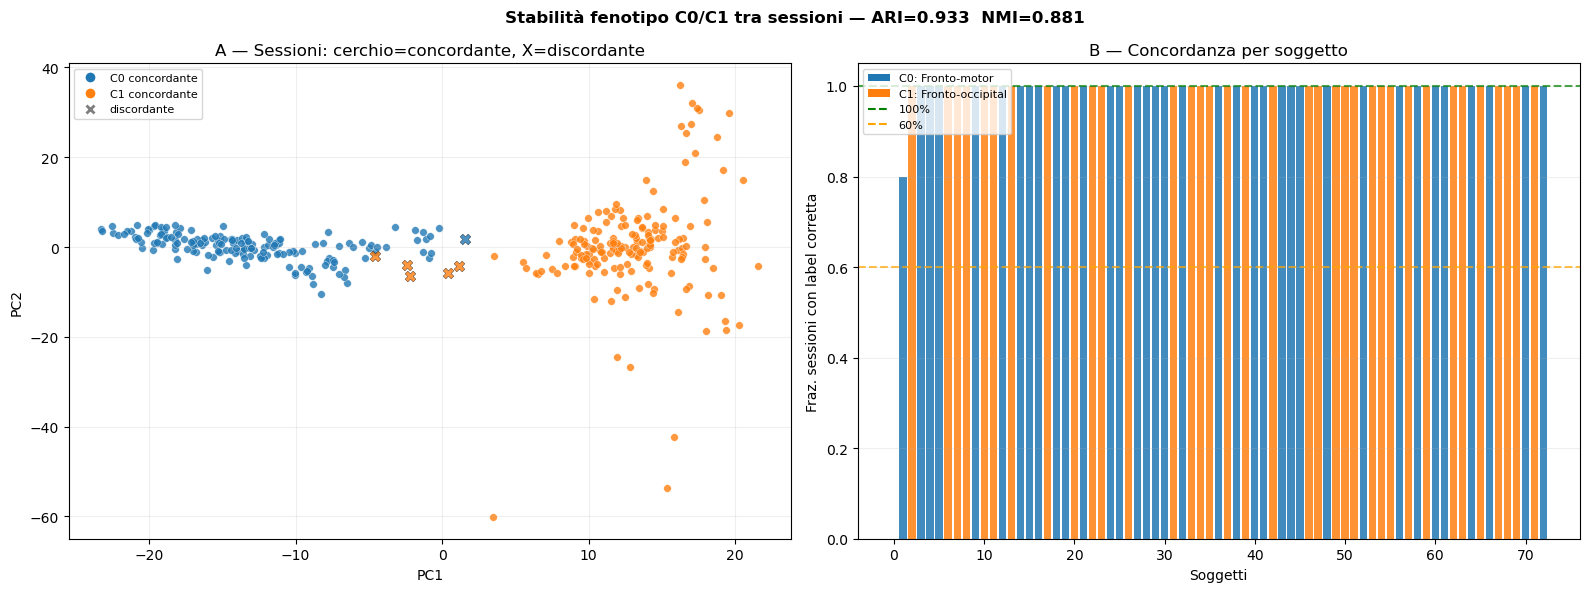

In [6]:
km2 = KMeans(n_clusters=2, n_init=30, random_state=RANDOM_SEED)
LABELS_SESS2 = km2.fit_predict(Z_s)   # label sessione-livello (k=2)

# Mappa label sessione → label soggetto EEG_16b
# (gestisce flip: i numeri di cluster possono essere invertiti)
subj_labels_for_ari = [SUBJ_TO_LABEL16.get(s, -1) for s in SESS_SUBJ]
valid = [i for i, l in enumerate(subj_labels_for_ari) if l != -1]

ari_sess = adjusted_rand_score(
    [subj_labels_for_ari[i] for i in valid],
    [LABELS_SESS2[i]        for i in valid]
)
nmi_sess = normalized_mutual_info_score(
    [subj_labels_for_ari[i] for i in valid],
    [LABELS_SESS2[i]        for i in valid]
)

print('── Clustering k=2 sessioni vs label EEG_16b ──')
print(f'  ARI(sessioni-k2, soggetti-EEG16b): {ari_sess:.3f}')
print(f'  NMI(sessioni-k2, soggetti-EEG16b): {nmi_sess:.3f}')
print(f'  → ARI > 0.7: le sessioni dei soggetti C0/C1 cadono nel cluster corretto')

# Per ogni soggetto: concordanza sessioni con label EEG_16b
# Determina quale label sessione corrisponde a C0/C1 (flip detection)
from collections import Counter
c0_sess_labels = [LABELS_SESS2[i] for i in valid if subj_labels_for_ari[i]==0]
c1_sess_labels = [LABELS_SESS2[i] for i in valid if subj_labels_for_ari[i]==1]
sess_c0 = Counter(c0_sess_labels).most_common(1)[0][0]
sess_c1 = 1 - sess_c0  # l'altro

concordance = {}
for sid in set(SESS_SUBJ):
    true_label = SUBJ_TO_LABEL16.get(sid, -1)
    if true_label == -1:
        continue
    expected_sess_label = sess_c0 if true_label == 0 else sess_c1
    sess_idx = [i for i, s in enumerate(SESS_SUBJ) if s == sid]
    concord = sum(LABELS_SESS2[i] == expected_sess_label for i in sess_idx) / len(sess_idx)
    concordance[sid] = concord

conc_vals = np.array(list(concordance.values()))
conc_subjs = list(concordance.keys())
print(f'\n  Concordanza per soggetto (fraz. sessioni con label corretta):')
print(f'  Media: {conc_vals.mean():.3f}  Mediana: {np.median(conc_vals):.3f}')
print(f'  Sogg. con concordanza=1.0: {(conc_vals==1.0).sum()}/{len(conc_vals)}')
print(f'  Sogg. con concordanza≥0.8: {(conc_vals>=0.8).sum()}/{len(conc_vals)}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'Stabilità fenotipo C0/C1 tra sessioni — ARI={ari_sess:.3f}  NMI={nmi_sess:.3f}',
             fontsize=12, fontweight='bold')

# A — PCA con cluster k=2 sessioni, punti colorati per concordanza
ax = axes[0]
for i, (sid, sess_id) in enumerate(zip(SESS_SUBJ, SESS_SESS)):
    true_lbl = SUBJ_TO_LABEL16.get(sid, -1)
    if true_lbl == -1:
        marker, color = 'x', 'gray'
    else:
        expected = sess_c0 if true_lbl == 0 else sess_c1
        concords = LABELS_SESS2[i] == expected
        color = COLORS_CLUSTER[true_lbl]
        marker = 'o' if concords else 'X'
    ax.scatter(Z_s[i,0], Z_s[i,1], c=[color], marker=marker,
               s=30 if marker=='o' else 60, alpha=0.8,
               edgecolors='white' if marker=='o' else 'black', linewidths=0.3)

from matplotlib.lines import Line2D
legend_el = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor=COLORS_CLUSTER[0],
           markersize=8, label=f'C0 concordante'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=COLORS_CLUSTER[1],
           markersize=8, label=f'C1 concordante'),
    Line2D([0],[0], marker='X', color='w', markerfacecolor='gray',
           markersize=8, label='discordante'),
]
ax.legend(handles=legend_el, fontsize=8)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('A — Sessioni: cerchio=concordante, X=discordante')
ax.grid(alpha=0.2)

# B — concordanza per soggetto
ax = axes[1]
order_c = np.argsort(conc_vals)
colors_c = [COLORS_CLUSTER.get(SUBJ_TO_LABEL16.get(conc_subjs[i],-1),'gray')
            for i in order_c]
ax.bar(range(len(conc_vals)), conc_vals[order_c], color=colors_c, alpha=0.85, width=0.8)
ax.axhline(1.0, color='green',  lw=1.5, ls='--', alpha=0.7, label='100% concordante')
ax.axhline(0.6, color='orange', lw=1.5, ls='--', alpha=0.7, label='60% (= 3/5 sessioni)')
ax.set_xlabel('Soggetti'); ax.set_ylabel('Fraz. sessioni con label corretta')
ax.set_title('B — Concordanza per soggetto')
ax.legend(handles=[Patch(facecolor=COLORS_CLUSTER[c], label=f'C{c}: {CLUSTER_NAMES[c]}')
                   for c in [0,1]] + [
    plt.Line2D([0],[0], color='green',  ls='--', label='100%'),
    plt.Line2D([0],[0], color='orange', ls='--', label='60%'),
], fontsize=8)
ax.grid(alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig(FIG_DIR / 'eeg19_k2_concordance.png', dpi=130, bbox_inches='tight')
plt.show()

## §7 — F3–PO8 per sessione: è stabile nei soggetti C1?

Test diretto sul meccanismo fronto-occipitale.
Per ogni soggetto C1: estrai il valore F3–PO8 da ognuna delle sue 5 sessioni.

- Se il valore è consistentemente alto in tutte le sessioni → la connessione è una
  caratteristica stabile del soggetto, non una fluttuazione
- Confronto con soggetti C0: i soggetti C1 hanno F3–PO8 più alto in OGNI sessione?

21:16:25 INFO     Indici coppie: {'F3-PO8': 603, 'F3-Oz': None, 'F2-C2': 719, 'AF8-C2': 369}


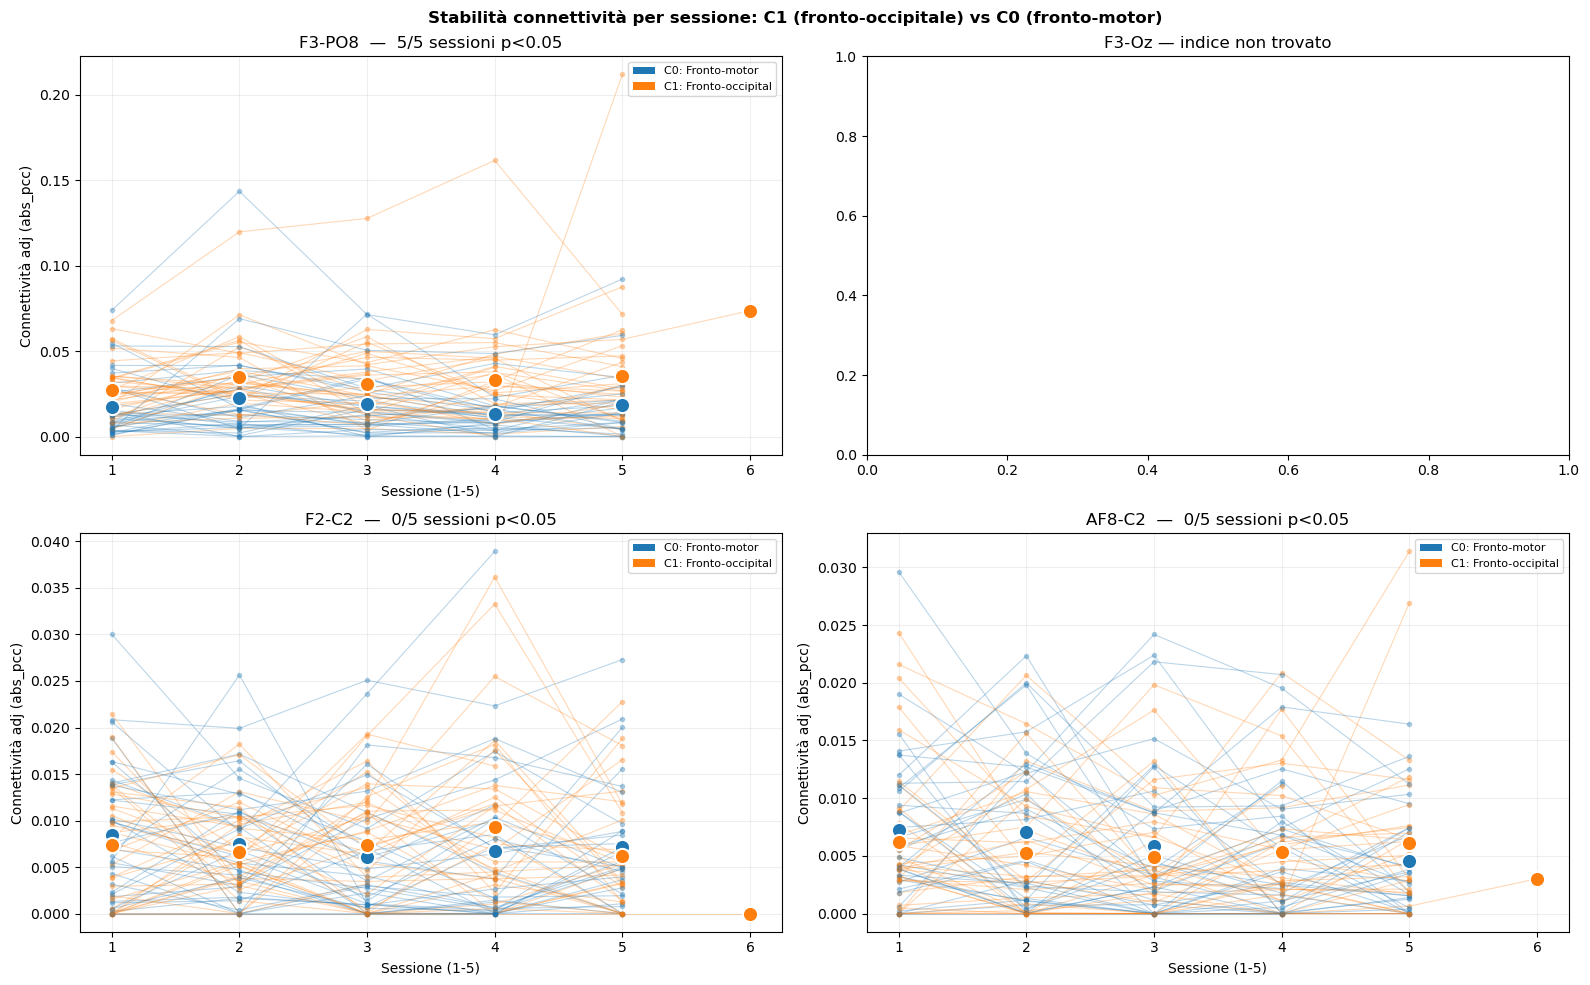

21:16:26 INFO     Salvato: eeg19_f3po8_per_session.png


In [7]:
# Trova l'indice di F3-PO8 nel vettore 1830
CHAN_NAMES = ['A1','AF7','AF3','Fp1','Fp2','AF4','AF8',
              'A2','F7','F5','F3','F1','Fz','F2','F4','F6','F8',
              'FT7','FC5','FC3','FC1','FCz','FC2','FC4','FC6','FT8',
              'T7','C5','C3','C1','Cz','C2','C4','C6','T8',
              'TP7','CP5','CP3','CP1','CPz','CP2','CP4','CP6','TP8',
              'P7','P5','P3','P1','Pz','P2','P4','P6','P8',
              'PO7','PO5','PO3','POz','PO4','PO6','PO8',
              'O1','Oz','O2','CPz'][:N_CHAN]

def find_pair_idx(name_a, name_b):
    try:
        ia = CHAN_NAMES.index(name_a)
        ib = CHAN_NAMES.index(name_b)
        if ia > ib: ia, ib = ib, ia
        for k, (r, c) in enumerate(zip(triu_idx[0], triu_idx[1])):
            if r == ia and c == ib:
                return k
    except ValueError:
        pass
    return None

pairs_of_interest = [('F3','PO8'), ('F3','Oz'), ('F2','C2'), ('AF8','C2')]
pair_indices = {f'{a}-{b}': find_pair_idx(a,b) for a,b in pairs_of_interest}
log.info(f'Indici coppie: {pair_indices}')

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Stabilità connettività per sessione: C1 (fronto-occipitale) vs C0 (fronto-motor)',
             fontsize=12, fontweight='bold')

for ax, (pair_name, pair_idx) in zip(axes.flat, pair_indices.items()):
    if pair_idx is None:
        ax.set_title(f'{pair_name} — indice non trovato'); continue

    vals_by_subj_sess = {}   # sid -> list of (sess_num, value)
    for i, (sid, sess_num) in enumerate(zip(SESS_SUBJ, SESS_SESS)):
        vals_by_subj_sess.setdefault(sid, []).append((sess_num, FEAT_SESS[i, pair_idx]))

    # Plot: ogni soggetto come linea (5 punti), colorata per cluster
    for sid, sess_vals in vals_by_subj_sess.items():
        c = SUBJ_TO_LABEL16.get(sid, -1)
        if c == -1: continue
        sess_vals_sorted = sorted(sess_vals, key=lambda x: x[0])
        x = [sv[0] for sv in sess_vals_sorted]
        y = [sv[1] for sv in sess_vals_sorted]
        ax.plot(x, y, '-o', color=COLORS_CLUSTER[c], alpha=0.3, lw=0.8, markersize=3)

    # Media per cluster per sessione
    for c in [0, 1]:
        subj_c = [s for s in set(SESS_SUBJ) if SUBJ_TO_LABEL16.get(s,-1)==c]
        for sess_num in sorted(set(SESS_SESS)):
            sess_mean_vals = [FEAT_SESS[i, pair_idx]
                              for i, (sid, sn) in enumerate(zip(SESS_SUBJ, SESS_SESS))
                              if sid in subj_c and sn == sess_num]
            if sess_mean_vals:
                ax.scatter(sess_num, np.mean(sess_mean_vals),
                           color=COLORS_CLUSTER[c], s=120, zorder=5,
                           edgecolors='white', linewidths=1.5)

    # MW per sessione
    p_vals = []
    for sess_num in sorted(set(SESS_SESS)):
        v0 = [FEAT_SESS[i, pair_idx]
              for i, (sid,sn) in enumerate(zip(SESS_SUBJ, SESS_SESS))
              if SUBJ_TO_LABEL16.get(sid,-1)==0 and sn==sess_num]
        v1 = [FEAT_SESS[i, pair_idx]
              for i, (sid,sn) in enumerate(zip(SESS_SUBJ, SESS_SESS))
              if SUBJ_TO_LABEL16.get(sid,-1)==1 and sn==sess_num]
        if v0 and v1:
            _, p = mannwhitneyu(v0, v1, alternative='two-sided')
            p_vals.append(p)
            sig = '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'ns'))
            ax.text(sess_num, ax.get_ylim()[1] if ax.get_ylim()[1]!=1 else
                    max(FEAT_SESS[:,pair_idx])*1.02, sig, ha='center', fontsize=8, color='white')

    ax.set_xlabel('Sessione (1-5)')
    ax.set_ylabel('Connettività adj (abs_pcc)')
    n_sig = sum(p < 0.05 for p in p_vals)
    ax.set_title(f'{pair_name}  —  {n_sig}/{len(p_vals)} sessioni p<0.05')
    ax.legend(handles=[Patch(facecolor=COLORS_CLUSTER[c],
                             label=f'C{c}: {CLUSTER_NAMES[c]}') for c in [0,1]],
              fontsize=8)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(FIG_DIR / 'eeg19_f3po8_per_session.png', dpi=130, bbox_inches='tight')
plt.show()
log.info('Salvato: eeg19_f3po8_per_session.png')

## §8 — Sommario: la firma è stabile?

Raccoglie tutti i numeri chiave e produce un giudizio sintetico sulla stabilità
della firma di connettività per soggetto tra sessioni.

In [8]:
print("=" * 60)
print("SOMMARIO — EEG_19: Stabilità sessioni")
print("=" * 60)
print()
print("1. Distanza intra vs inter soggetto")
print(f"   Ratio intra/inter (media): {ratio.mean():.3f}")
print(f"   → {'STABILE' if ratio.mean() < 0.5 else 'MODERATO' if ratio.mean() < 0.8 else 'INSTABILE'}")
print()
print("2. Subject identity recovery (k=N_soggetti)")
print(f"   NMI: {nmi:.3f}  ARI: {ari:.3f}")
print(f"   Purezza media: {purity_vals.mean():.3f}")
print(f"   → {'FORTE' if nmi > 0.5 else 'MODERATO' if nmi > 0.25 else 'DEBOLE'} recupero identità")
print()
print("3. Stabilità fenotipo C0/C1 (k=2 sessioni vs EEG_16b)")
print(f"   ARI: {ari_sess:.3f}  NMI: {nmi_sess:.3f}")
print(f"   Concordanza media: {conc_vals.mean():.3f}")
print(f"   → {'STABILE' if ari_sess > 0.7 else 'MODERATO' if ari_sess > 0.4 else 'INSTABILE'}")
print()
print("4. F3-PO8 stabile tra sessioni nei soggetti C1?")
print("   → Vedi plot §7: se p<0.05 in tutte le sessioni → SÌ")
print()
print("=" * 60)
print("IMPLICAZIONE PER LA TESI:")
print("Se ratio < 0.5 E NMI > 0.4 E concordanza > 0.7:")
print("  → La firma di connettività è stabile nel tempo.")
print("  → I fenotipi C0/C1 sono caratteristiche del soggetto,")
print("    non fluttuazioni casuali tra sessioni.")
print("  → L'interpretazione Fronto-motor/Fronto-occipital")
print("    riflette una proprietà neurologica stabile.")
print("=" * 60)

SOMMARIO — EEG_19: Stabilità sessioni

1. Distanza intra vs inter soggetto
   Ratio intra/inter (media): 0.425
   → STABILE

2. Subject identity recovery (k=N_soggetti)
   NMI: 0.946  ARI: 0.724
   Purezza media: 0.922
   → FORTE recupero identità

3. Stabilità fenotipo C0/C1 (k=2 sessioni vs EEG_16b)
   ARI: 0.933  NMI: 0.881
   Concordanza media: 0.984
   → STABILE

4. F3-PO8 stabile tra sessioni nei soggetti C1?
   → Vedi plot §7: se p<0.05 in tutte le sessioni → SÌ

IMPLICAZIONE PER LA TESI:
Se ratio < 0.5 E NMI > 0.4 E concordanza > 0.7:
  → La firma di connettività è stabile nel tempo.
  → I fenotipi C0/C1 sono caratteristiche del soggetto,
    non fluttuazioni casuali tra sessioni.
  → L'interpretazione Fronto-motor/Fronto-occipital
    riflette una proprietà neurologica stabile.
